# YAFS Simulation Trace Analysis

This notebook analyzes the `sim_trace.csv` file generated by the YAFS simulation. It focuses on:
- **Latency Analysis**: End-to-end delay of messages.
- **Service Time**: Processing time within modules.
- **Traffic Distribution**: Message counts per application and module.
- **Topology Flow**: Communication patterns between Fog and Cloud nodes.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Inspect Data
Load the CSV file and check the structure.

In [10]:
# Load the dataset
# Update to the specific results file generated by the tutorial
file_path = 'resultados/4-custom_proposed_by_felipe-sim_trace.csv'
df = pd.read_csv(file_path)

# Display first rows
display(df.head())

# Check info
print(df.info())

,id,type,app,module,message,DES.src,DES.dst,TOPO.src,TOPO.dst,TOPO.srcLabel,TOPO.dstLabel,module.src,service,time_in,time_out,time_emit,time_reception
0,-1,COMP_M,Application-66,Application-66-Service,M_Req,277,275,156,2,Application-66-Sensor,Fog-1,Application-66-Sensor,0.018182,108.740828,108.759010,0.0,108.740828
1,-1,COMP_M,Application-61,Application-61-Service,M_Req,262,260,146,2,Application-61-Sensor,Fog-1,Application-61-Sensor,0.017659,109.259277,109.276936,0.0,109.259277
2,-1,COMP_M,Application-34,Application-34-Service,M_Req,181,179,92,2,Application-34-Sensor,Fog-1,Application-34-Sensor,0.023996,109.454809,109.478805,0.0,109.454809
3,-1,COMP_M,Application-23,Application-23-Service,M_Req,148,146,70,2,Application-23-Sensor,Fog-1,Application-23-Sensor,0.018570,109.692281,109.710851,0.0,109.692281
4,-1,COMP_M,Application-73,Application-73-Service,M_Req,298,296,170,3,Application-73-Sensor,Fog-2,Application-73-Sensor,0.015950,109.904242,109.920192,0.0,109.904242


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15836 entries, 0 to 15835
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              15836 non-null  int64  
 1   type            15836 non-null  object 
 2   app             15836 non-null  object 
 3   module          15836 non-null  object 
 4   message         15836 non-null  object 
 5   DES.src         15836 non-null  int64  
 6   DES.dst         15836 non-null  int64  
 7   TOPO.src        15836 non-null  int64  
 8   TOPO.dst        15836 non-null  int64  
 9   TOPO.srcLabel   15836 non-null  object 
 10  TOPO.dstLabel   15836 non-null  object 
 11  module.src      15836 non-null  object 
 12  service         15836 non-null  float64
 13  time_in         15836 non-null  float64
 14  time_out        15836 non-null  float64
 15  time_emit       15836 non-null  float64
 16  time_reception  15836 non-null  float64
dtypes: float64(5), int64(5), object

## 2. Data Preprocessing
Calculate key metrics:
- **Latency**: `time_reception - time_emit`
- **Service Time**: `time_out - time_in`
- **Network/Wait Time**: `Latency - Service Time`

In [11]:
# Calculate Latency
df['Latency'] = df['time_reception'] - df['time_emit']

# Calculate Service Time (Processing Duration)
df['Service_Time'] = df['time_out'] - df['time_in']

# Calculate Network + Wait Time
df['Network_Wait_Time'] = df['Latency'] - df['Service_Time']

# Create a combined label for Application and Node
df['App_Node'] = df['app'] + ' (' + df['TOPO.dstLabel'] + ')'

# Display summary stats for these new metrics
df[['Latency', 'Service_Time', 'Network_Wait_Time']].describe()

,Latency,Service_Time,Network_Wait_Time
count,15836.000000,15836.000000,15836.000000
mean,5032.851337,0.163916,5032.687421
std,2857.177025,0.146231,2857.176452
min,108.740828,0.013912,108.722646
25%,2540.162431,0.021780,2540.145700
50%,5028.614741,0.030783,5028.426399
75%,7520.045685,0.299908,7520.027204
max,9999.190934,0.437395,9998.878948


## 3. Descriptive Statistics
Analyze the frequency of applications, modules, and message types.

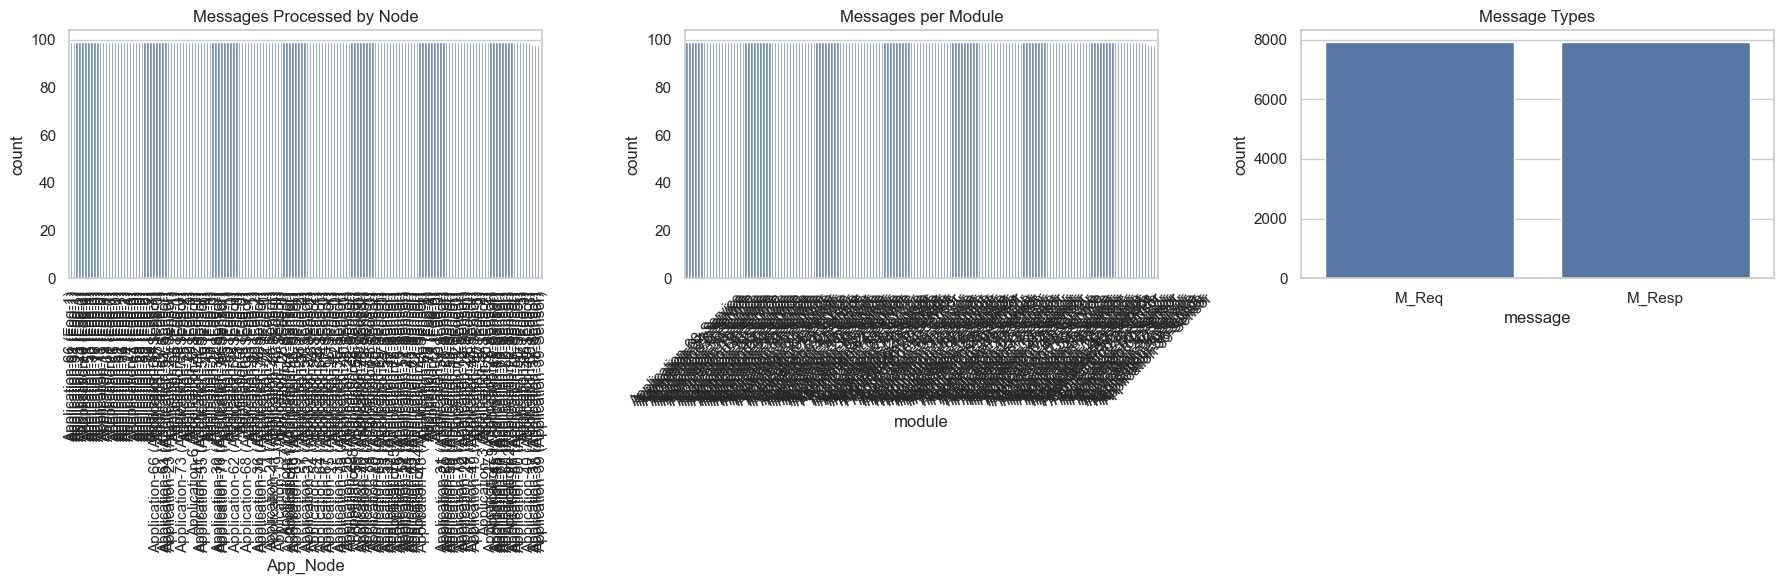

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Messages Processed by Node (Placement)
# We show all nodes now since Sensors and Actuators also process messages (M_Resp, M_Act)
sns.countplot(x='App_Node', data=df, ax=axes[0])
axes[0].set_title('Messages Processed by Node')
axes[0].tick_params(axis='x', rotation=90)

# 2. Messages per Module
sns.countplot(x='module', data=df, ax=axes[1])
axes[1].set_title('Messages per Module')
axes[1].tick_params(axis='x', rotation=45)

# 3. Message Types
# We use the 'message' column to distinguish M_Req, M_Resp, M_Act
sns.countplot(x='message', data=df, ax=axes[2])
axes[2].set_title('Message Types')

plt.tight_layout()
plt.show()

## 4. Latency Analysis
Visualize the distribution of latency and compare it across applications.

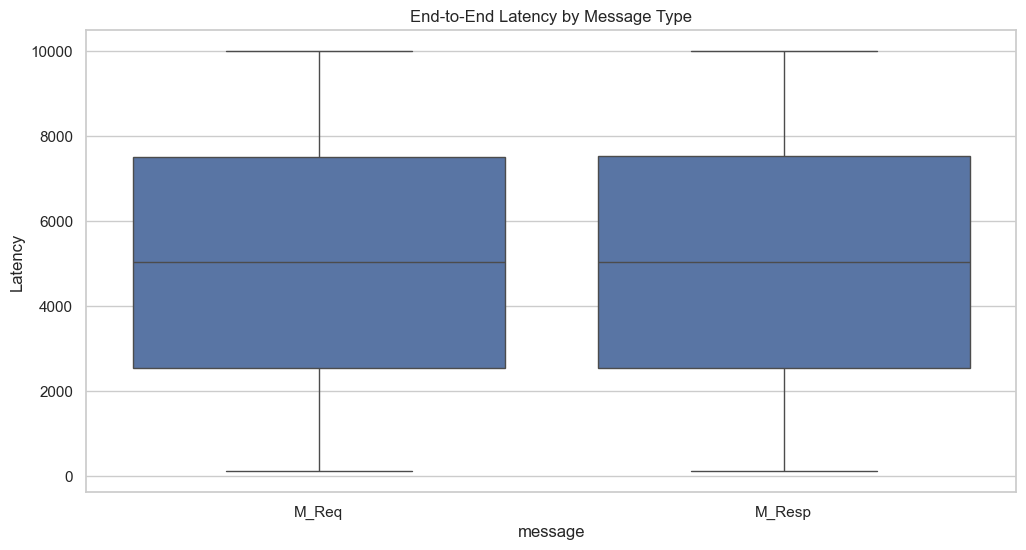

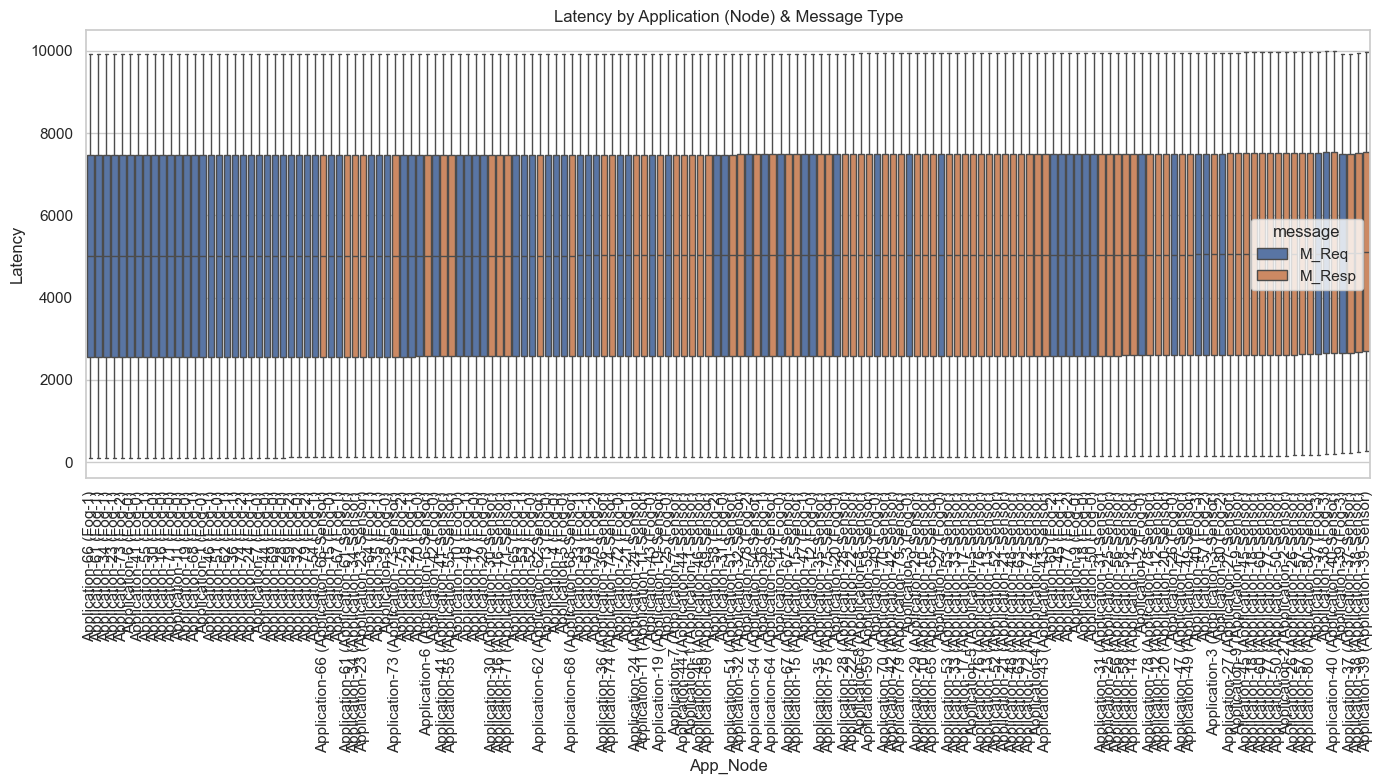

In [13]:
# Latency Distribution by Message Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='message', y='Latency', data=df)
plt.title('End-to-End Latency by Message Type')
plt.show()

# Latency by Application and Node
plt.figure(figsize=(14, 8))
sns.boxplot(x='App_Node', y='Latency', hue='message', data=df)
plt.title('Latency by Application (Node) & Message Type')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5. Service Time Analysis
Compare processing times across different nodes (Fog vs Cloud).

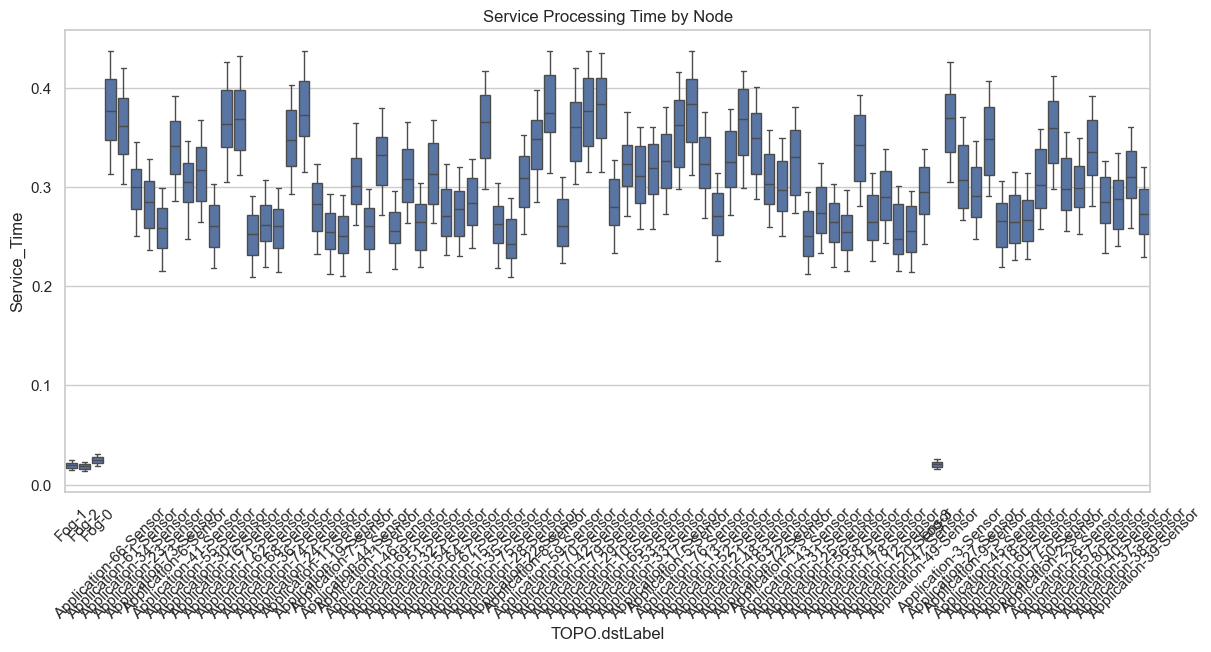

In [14]:
# Service Time by Node Label
plt.figure(figsize=(14, 6))
sns.boxplot(x='TOPO.dstLabel', y='Service_Time', data=df)
plt.title('Service Processing Time by Node')
plt.xticks(rotation=45)
plt.show()

## 6. Traffic Load Over Time
Check if the traffic is constant or bursty.

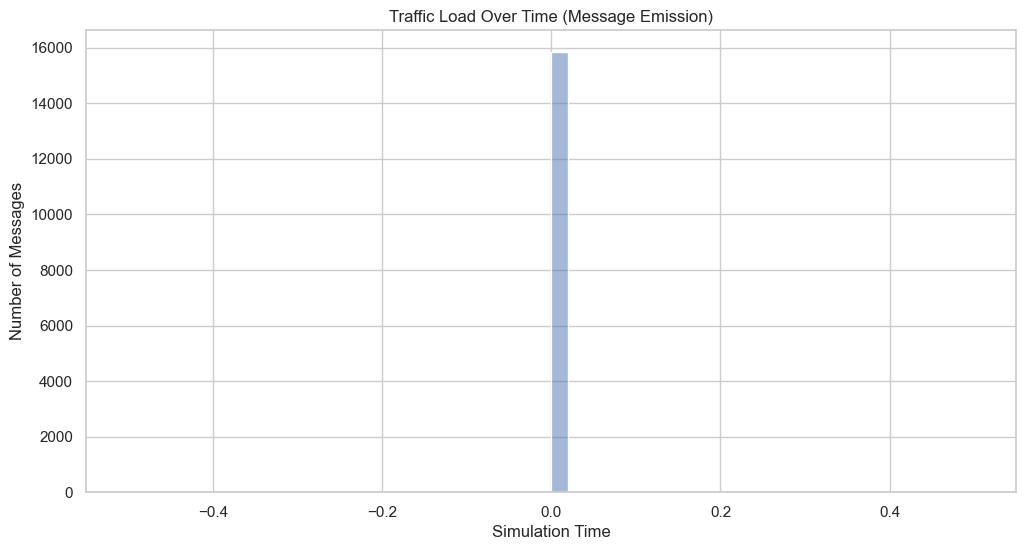

In [15]:
plt.figure(figsize=(12, 6))
sns.histplot(df['time_emit'], bins=50, kde=True)
plt.title('Traffic Load Over Time (Message Emission)')
plt.xlabel('Simulation Time')
plt.ylabel('Number of Messages')
plt.show()

## 7. Network Topology Flow
Visualize the communication frequency between different nodes.

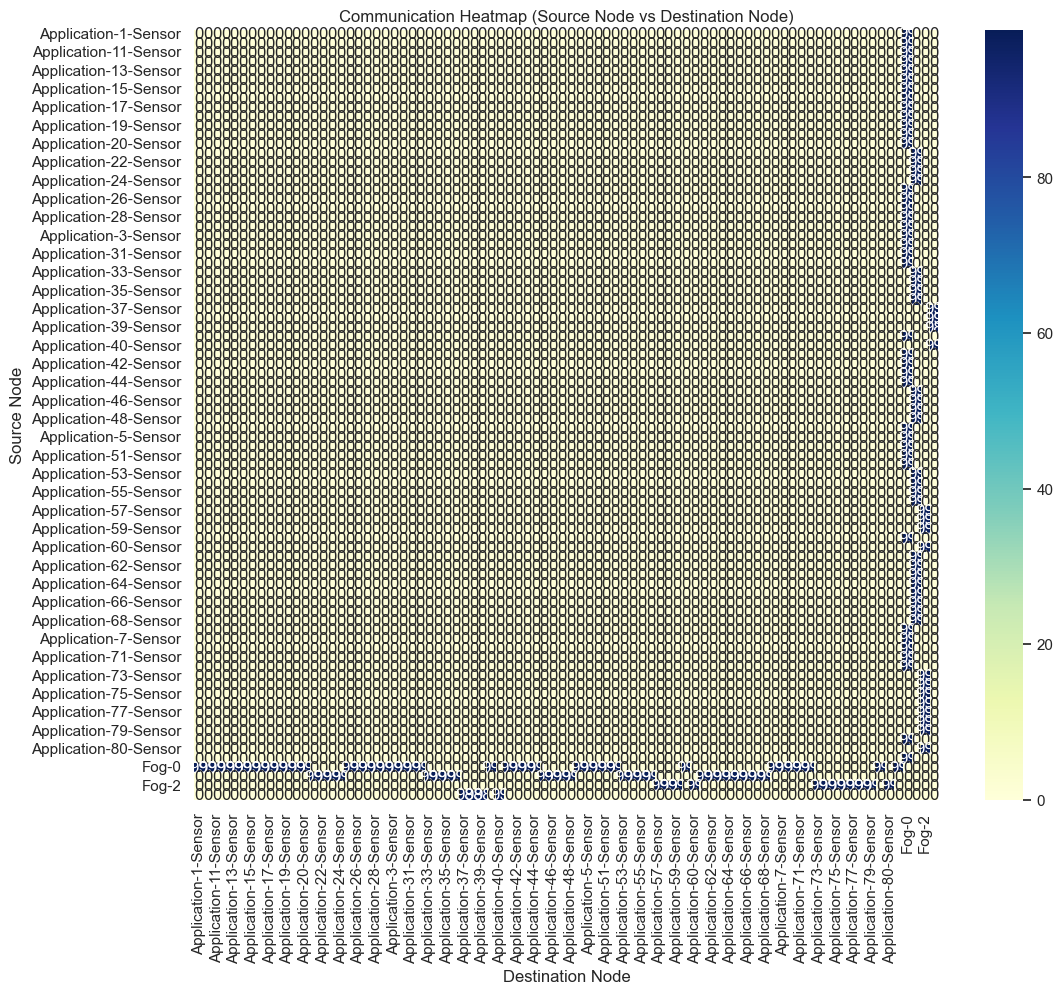

In [16]:
# Create a pivot table for the heatmap
heatmap_data = pd.crosstab(df['TOPO.srcLabel'], df['TOPO.dstLabel'])

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Communication Heatmap (Source Node vs Destination Node)')
plt.xlabel('Destination Node')
plt.ylabel('Source Node')
plt.show()

## 8. Conclusion
This notebook provides a comprehensive overview of the simulation results.
- **Latency**: Check the boxplots to see if any application suffers from high latency.
- **Service Time**: Compare Fog vs Cloud nodes to see if Fog nodes are processing faster or if they are overloaded.
- **Traffic**: Ensure the load is distributed as expected and not saturating specific nodes (check the Heatmap).

## 6. Unprocessed Messages Analysis (Congestion/Loss)
Analyze messages that did not complete before the simulation ended. This indicates severe congestion or bottlenecks.

Total Unprocessed Messages: 3


,QueueType,App,Message,Src,Dst,Timestamp,Path,CurrentNode,Until
0,Network_Wait,Application-39,M_Req,Application-39-Sensor,Application-39-Service,0,"[102, 101, 14, 2, 0, 4]",0,10006.644721
1,Network_Wait,Application-37,M_Resp,Application-37-Service,Application-37-Sensor,0,"[4, 0, 2, 14, 97, 98]",2,10007.535454
2,Network_Wait,Application-38,M_Resp,Application-38-Service,Application-38-Sensor,0,"[4, 0, 2, 14, 99, 100]",0,10007.538983


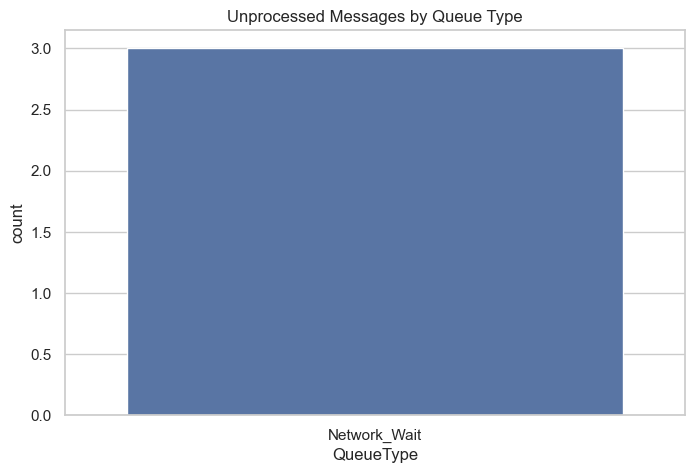

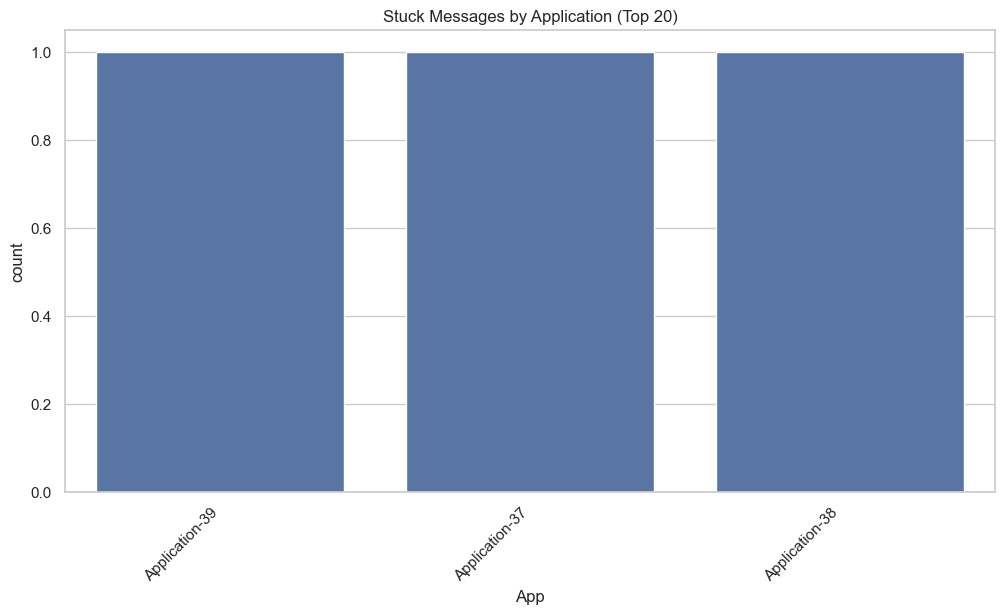

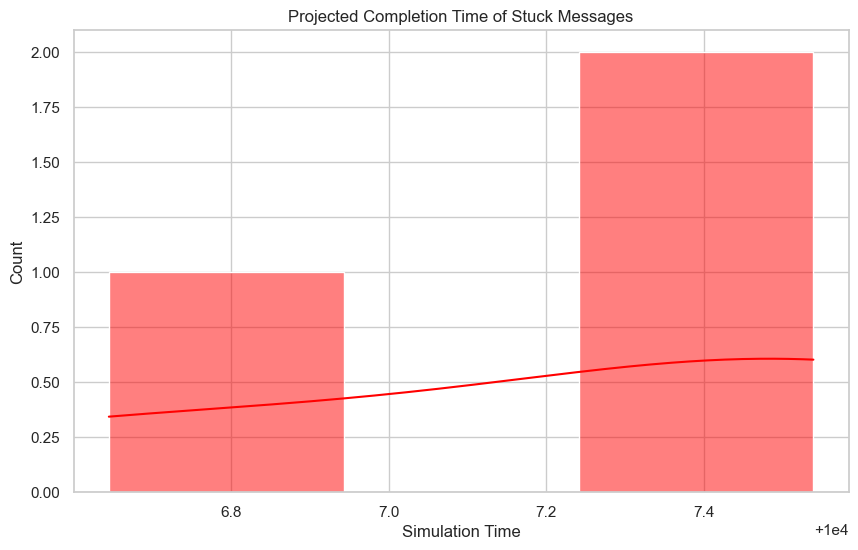

In [17]:
import os

unprocessed_path = 'resultados/unprocessed_messages.csv'

if os.path.exists(unprocessed_path):
    df_unprocessed = pd.read_csv(unprocessed_path)
    
    print(f"Total Unprocessed Messages: {len(df_unprocessed)}")
    
    if len(df_unprocessed) > 0:
        display(df_unprocessed.head())
        
        # 1. Count by Queue Type
        plt.figure(figsize=(8, 5))
        sns.countplot(x='QueueType', data=df_unprocessed)
        plt.title('Unprocessed Messages by Queue Type')
        plt.show()
        
        # 2. Count by Application (Top 20)
        top_stuck_apps = df_unprocessed['App'].value_counts().nlargest(20).index
        df_stuck_top20 = df_unprocessed[df_unprocessed['App'].isin(top_stuck_apps)]
        
        plt.figure(figsize=(12, 6))
        sns.countplot(x='App', data=df_stuck_top20, order=top_stuck_apps)
        plt.title('Stuck Messages by Application (Top 20)')
        plt.xticks(rotation=45, ha='right')
        plt.show()
        
        # 3. Distribution of "Until" time (Projected Completion Time)
        # Filter out N/A values if any
        df_unprocessed['Until'] = pd.to_numeric(df_unprocessed['Until'], errors='coerce')
        
        plt.figure(figsize=(10, 6))
        sns.histplot(df_unprocessed['Until'].dropna(), kde=True, color='red')
        plt.title('Projected Completion Time of Stuck Messages')
        plt.xlabel('Simulation Time')
        plt.show()
        
    else:
        print("No unprocessed messages found. Great!")
else:
    print("unprocessed_messages.csv not found.")